In [2]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# Load preprocessed data
data_dir = '../data/processed/'

X_train = pd.read_csv(data_dir + 'X_train.csv').to_numpy()
X_val = pd.read_csv(data_dir + 'X_val.csv').to_numpy()
X_test = pd.read_csv(data_dir + 'X_test.csv').to_numpy()

y_train = pd.read_csv(data_dir + 'y_train.csv').to_numpy().flatten()
y_val = pd.read_csv(data_dir + 'y_val.csv').to_numpy().flatten()
y_test = pd.read_csv(data_dir + 'y_test.csv').to_numpy().flatten()

In [4]:
# baseline model (one hidden layer with 10 neurons)
lambda_values = [0, 0.00001, 0.0001, 0.001, 0.1, 0.5, 1.0]
results = []

for lambda_val in lambda_values:
    baseline = MLPClassifier( # relu by default
        hidden_layer_sizes=(10,),
        alpha=lambda_val,
        max_iter=1000,
        random_state=67
    )
    baseline.fit(X_train, y_train)
    y_pred = baseline.predict(X_val)
    val_accuracy = accuracy_score(y_val, y_pred)
    val_precision = precision_score(y_val, y_pred)
    val_recall = recall_score(y_val, y_pred)
    val_f1 = f1_score(y_val, y_pred)
    results.append((lambda_val, val_accuracy, val_precision, val_recall, val_f1))

results_df = pd.DataFrame(results, columns=['lambda', 'val_accuracy', 'val_precision', 'val_recall', 'val_f1']).sort_values('lambda')
print(results_df.to_string(index=False))

 lambda  val_accuracy  val_precision  val_recall   val_f1
0.00000      0.924951       0.724138    0.860656 0.786517
0.00001      0.922976       0.718213    0.856557 0.781308
0.00010      0.924292       0.723183    0.856557 0.784240
0.00100      0.923634       0.719178    0.860656 0.783582
0.10000      0.927584       0.729452    0.872951 0.794776
0.50000      0.929559       0.730640    0.889344 0.802218
1.00000      0.922317       0.704545    0.889344 0.786232


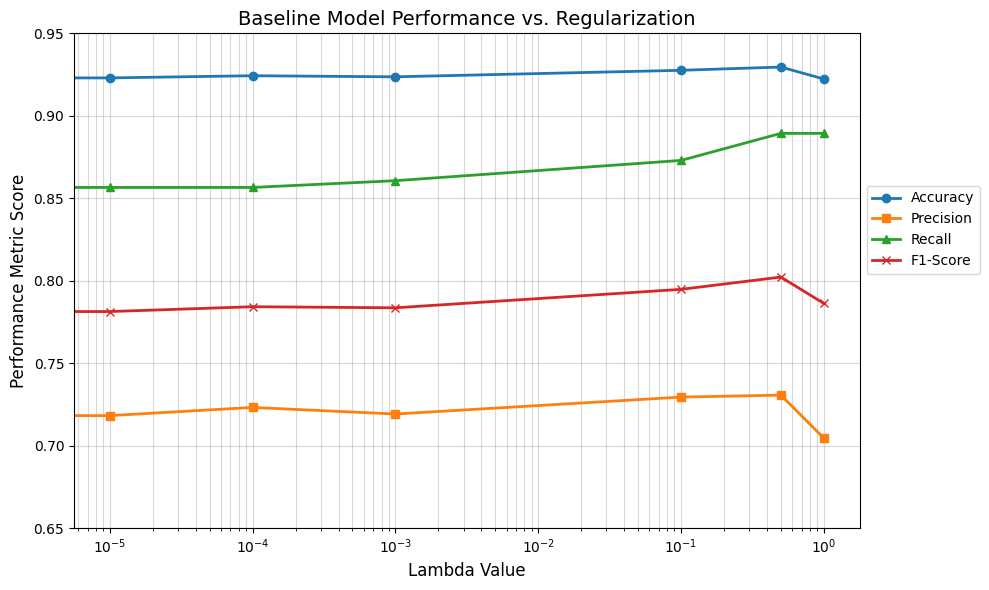

In [5]:
plt.figure(figsize=(10, 6))

# plot each metric against lambda
plt.plot(results_df['lambda'], results_df['val_accuracy'], label='Accuracy', marker='o', linewidth=2)
plt.plot(results_df['lambda'], results_df['val_precision'], label='Precision', marker='s', linewidth=2)
plt.plot(results_df['lambda'], results_df['val_recall'], label='Recall', marker='^', linewidth=2)
plt.plot(results_df['lambda'], results_df['val_f1'], label='F1-Score', marker='x', linewidth=2)

# log scale for x-axis because lambda values span several orders of magnitude
plt.xscale('log') 

# set y-axis limits and labels
plt.ylim(0.65, 0.95)
plt.xlabel('Lambda Value', fontsize=12)
plt.ylabel('Performance Metric Score', fontsize=12)
plt.title('Baseline Model Performance vs. Regularization', fontsize=14)

# add grid and legend
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(loc='lower left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

# show
plt.show()

In [6]:
# modified model 1 (one hidden layers with 50 neurons)
lambda_values = [0, 0.00001, 0.0001, 0.001, 0.1, 0.5, 1.0]
results_modified1 = []

for lambda_val in lambda_values:
    baseline = MLPClassifier(
        hidden_layer_sizes=(50,), # increase hidden layer size to 50 neurons
        alpha=lambda_val,
        max_iter=1000,              
        random_state=67
    )
    baseline.fit(X_train, y_train)
    y_pred = baseline.predict(X_val)
    val_accuracy = accuracy_score(y_val, y_pred)
    val_precision = precision_score(y_val, y_pred)
    val_recall = recall_score(y_val, y_pred)
    val_f1 = f1_score(y_val, y_pred)
    results_modified1.append((lambda_val, val_accuracy, val_precision, val_recall, val_f1))

results_modified1_df = pd.DataFrame(results_modified1, columns=['lambda', 'val_accuracy', 'val_precision', 'val_recall', 'val_f1']).sort_values('lambda')
print(results_modified1_df.to_string(index=False))

 lambda  val_accuracy  val_precision  val_recall   val_f1
0.00000      0.938776       0.784906    0.852459 0.817289
0.00001      0.938776       0.782772    0.856557 0.818004
0.00010      0.941409       0.806324    0.836066 0.820926
0.00100      0.938117       0.781955    0.852459 0.815686
0.10000      0.938117       0.786260    0.844262 0.814229
0.50000      0.927584       0.729452    0.872951 0.794776
1.00000      0.921659       0.710438    0.864754 0.780037


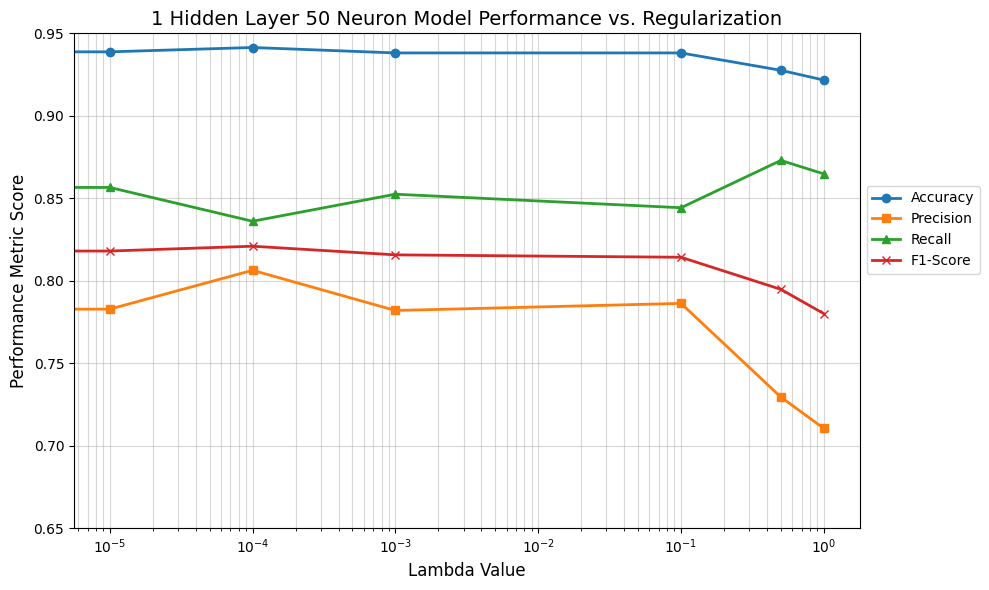

In [7]:
plt.figure(figsize=(10, 6))

# plot each metric against lambda
plt.plot(results_modified1_df['lambda'], results_modified1_df['val_accuracy'], label='Accuracy', marker='o', linewidth=2)
plt.plot(results_modified1_df['lambda'], results_modified1_df['val_precision'], label='Precision', marker='s', linewidth=2)
plt.plot(results_modified1_df['lambda'], results_modified1_df['val_recall'], label='Recall', marker='^', linewidth=2)
plt.plot(results_modified1_df['lambda'], results_modified1_df['val_f1'], label='F1-Score', marker='x', linewidth=2)

# log scale for x-axis because lambda values span several orders of magnitude
plt.xscale('log') 

# set y-axis limits and labels
plt.ylim(0.65, 0.95)
plt.xlabel('Lambda Value', fontsize=12)
plt.ylabel('Performance Metric Score', fontsize=12)
plt.title('1 Hidden Layer 50 Neuron Model Performance vs. Regularization', fontsize=14)

# add grid and legend
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(loc='lower left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

# show
plt.show()

In [8]:
# modified model 2 (two hidden layer with 20, 10 neurons)
lambda_values = [0, 0.00001, 0.0001, 0.001, 0.1, 0.5, 1.0]
results_modified2 = []

for lambda_val in lambda_values:
    baseline = MLPClassifier(
        hidden_layer_sizes=(20, 10), # two hidden layers with 20 and 10 neurons
        alpha=lambda_val,
        max_iter=1000,              
        random_state=67
    )
    baseline.fit(X_train, y_train)
    y_pred = baseline.predict(X_val)
    val_accuracy = accuracy_score(y_val, y_pred)
    val_precision = precision_score(y_val, y_pred)
    val_recall = recall_score(y_val, y_pred)
    val_f1 = f1_score(y_val, y_pred)
    results_modified2.append((lambda_val, val_accuracy, val_precision, val_recall, val_f1))

results_modified2_df = pd.DataFrame(results_modified2, columns=['lambda', 'val_accuracy', 'val_precision', 'val_recall', 'val_f1']).sort_values('lambda')
print(results_modified2_df.to_string(index=False))

 lambda  val_accuracy  val_precision  val_recall   val_f1
0.00000      0.938117       0.784091    0.848361 0.814961
0.00001      0.936801       0.782443    0.840164 0.810277
0.00010      0.944700       0.812500    0.852459 0.832000
0.00100      0.946017       0.816406    0.856557 0.836000
0.10000      0.944042       0.804598    0.860656 0.831683
0.50000      0.943384       0.782143    0.897541 0.835878
1.00000      0.934167       0.750000    0.885246 0.812030


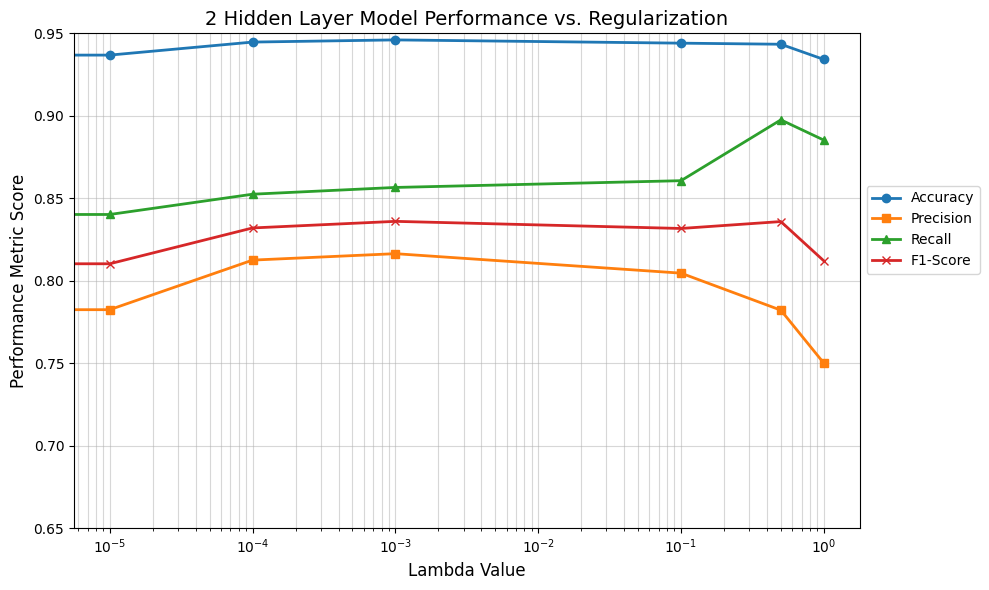

In [9]:
plt.figure(figsize=(10, 6))

# plot each metric against lambda
plt.plot(results_modified2_df['lambda'], results_modified2_df['val_accuracy'], label='Accuracy', marker='o', linewidth=2)
plt.plot(results_modified2_df['lambda'], results_modified2_df['val_precision'], label='Precision', marker='s', linewidth=2)
plt.plot(results_modified2_df['lambda'], results_modified2_df['val_recall'], label='Recall', marker='^', linewidth=2)
plt.plot(results_modified2_df['lambda'], results_modified2_df['val_f1'], label='F1-Score', marker='x', linewidth=2)

# log scale for x-axis because lambda values span several orders of magnitude
plt.xscale('log') 

# set y-axis limits and labels
plt.ylim(0.65, 0.95)
plt.xlabel('Lambda Value', fontsize=12)
plt.ylabel('Performance Metric Score', fontsize=12)
plt.title('2 Hidden Layer Model Performance vs. Regularization', fontsize=14)

# add grid and legend
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(loc='lower left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

# show
plt.show()

In [10]:
# modified model 3 (three hidden layers with 20, 10, 5 neurons)
lambda_values = [0, 0.00001, 0.0001, 0.001, 0.1, 0.5, 1.0]
results_modified3 = []

for lambda_val in lambda_values:
    baseline = MLPClassifier(
        hidden_layer_sizes=(20, 10, 5), # three hidden layers with 20, 10, and 5 neurons
        alpha=lambda_val,
        max_iter=1000,              
        random_state=67
    )
    baseline.fit(X_train, y_train)
    y_pred = baseline.predict(X_val)
    val_accuracy = accuracy_score(y_val, y_pred)
    val_precision = precision_score(y_val, y_pred)
    val_recall = recall_score(y_val, y_pred)
    val_f1 = f1_score(y_val, y_pred)
    results_modified3.append((lambda_val, val_accuracy, val_precision, val_recall, val_f1))

results_modified3_df = pd.DataFrame(results_modified3, columns=['lambda', 'val_accuracy', 'val_precision', 'val_recall', 'val_f1']).sort_values('lambda')
print(results_modified3_df.to_string(index=False))

 lambda  val_accuracy  val_precision  val_recall   val_f1
0.00000      0.932192       0.756364    0.852459 0.801541
0.00001      0.936801       0.791339    0.823770 0.807229
0.00010      0.940750       0.805556    0.831967 0.818548
0.00100      0.934167       0.788000    0.807377 0.797571
0.10000      0.927584       0.748148    0.827869 0.785992
0.50000      0.938776       0.768683    0.885246 0.822857
1.00000      0.931534       0.751799    0.856557 0.800766


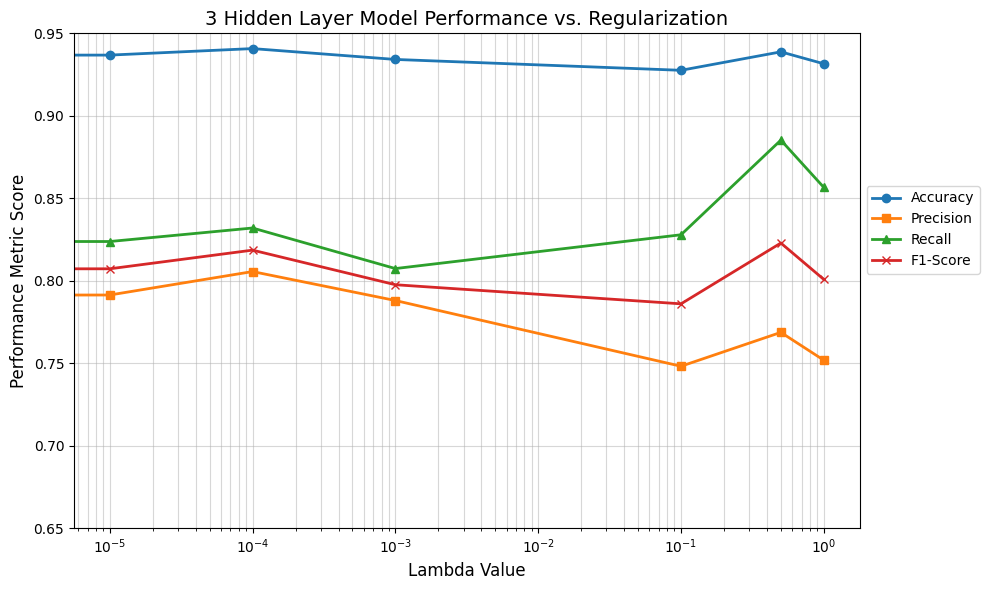

In [11]:
plt.figure(figsize=(10, 6))

# plot each metric against lambda
plt.plot(results_modified3_df['lambda'], results_modified3_df['val_accuracy'], label='Accuracy', marker='o', linewidth=2)
plt.plot(results_modified3_df['lambda'], results_modified3_df['val_precision'], label='Precision', marker='s', linewidth=2)
plt.plot(results_modified3_df['lambda'], results_modified3_df['val_recall'], label='Recall', marker='^', linewidth=2)
plt.plot(results_modified3_df['lambda'], results_modified3_df['val_f1'], label='F1-Score', marker='x', linewidth=2)

# log scale for x-axis because lambda values span several orders of magnitude
plt.xscale('log') 

# set y-axis limits and labels
plt.ylim(0.65, 0.95)
plt.xlabel('Lambda Value', fontsize=12)
plt.ylabel('Performance Metric Score', fontsize=12)
plt.title('3 Hidden Layer Model Performance vs. Regularization', fontsize=14)

# add grid and legend
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(loc='lower left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

# show
plt.show()

In [ ]:
# train and evaluate best model on test set
best_lambda = 0.001
best_result = []
bestModel = MLPClassifier(
    hidden_layer_sizes=(20, 10), # two hidden layers with 20 and 10 neurons
    alpha=best_lambda,
    max_iter=1000,              
    random_state=67
)
bestModel.fit(X_train, y_train)
y_pred = bestModel.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
best_result.append((best_lambda, test_accuracy, test_precision, test_recall, test_f1))

best_result_df = pd.DataFrame(best_result, columns=['lambda', 'test_accuracy', 'test_precision', 'test_recall', 'test_f1']).sort_values('lambda')
print(best_result_df.to_string(index=False))

 lambda  test_accuracy  test_precision  test_recall  test_f1
  0.001       0.932237        0.787755     0.790984 0.789366
